In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

plt.rcParams['svg.fonttype'] = 'none'

In [9]:
dfJia = pd.read_csv('/Users/trev/Downloads/Jianhan-CRX.csv')
dfJia = dfJia.rename(columns={'Name': 'construct'})
dfTB = pd.read_csv('../Data/constructs_df.csv', index_col=0)

df_merged = dfTB.merge(dfJia, on='construct', how='inner')

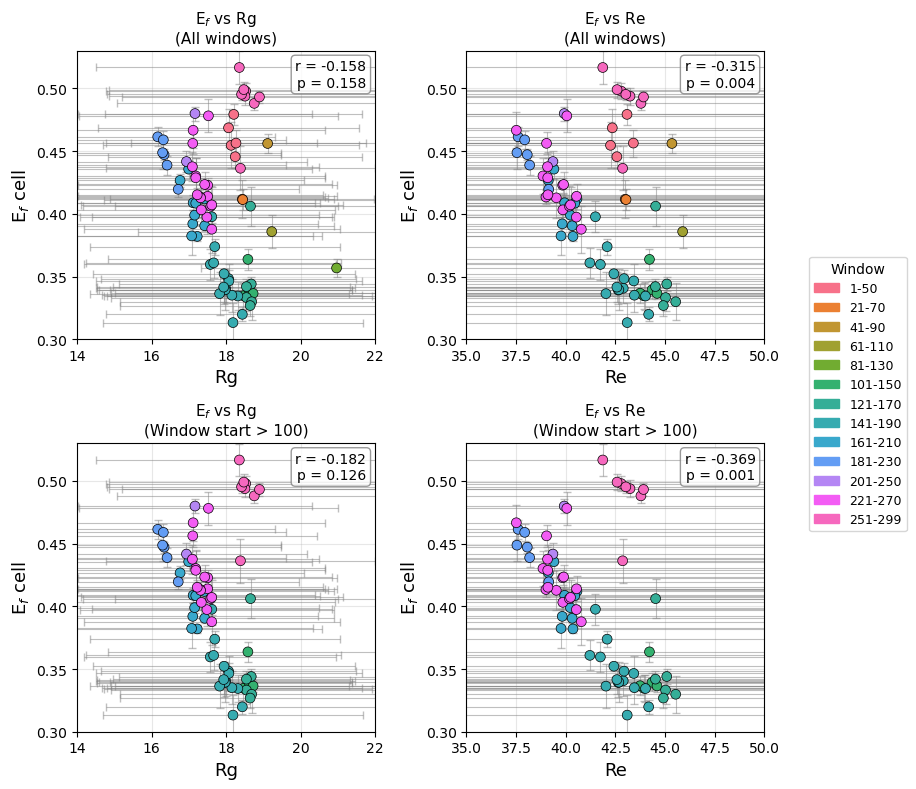

In [29]:
from scipy.stats import pearsonr
import matplotlib.patches as mpatches


df_merged['window'] = df_merged['construct'].str.extract(r'^(\d+-\d+)_')
df_merged['win_start'] = df_merged['window'].str.extract(r'^(\d+)-').astype(float)

windows = sorted(df_merged['window'].dropna().unique(),
                 key=lambda w: int(w.split('-')[0]))
import seaborn as sns

palette   = sns.color_palette('husl', len(windows))
win_color = {w: palette[i] for i, w in enumerate(windows)}

PLOT_SPECS = [
    ('Rg_mean', 'Rg_std', 'Rg', (14, 22)),
    ('Re_mean', 'Re_std', 'Re', (35, 50)),
]
ROW_SPECS = [
    ('All windows',        df_merged),
    ('Window start > 100', df_merged[df_merged['win_start'] > 100]),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for row_idx, (row_label, df_row) in enumerate(ROW_SPECS):
    colors_row = df_row['window'].map(win_color)

    for col_idx, (x_col, x_err_col, x_label, xlim) in enumerate(PLOT_SPECS):
        ax = axes[row_idx][col_idx]

        valid = df_row[[x_col, 'Ef_cell']].dropna()
        r, p  = pearsonr(valid[x_col], valid['Ef_cell'])
        p_str = f'p = {p:.3f}' if p >= 0.001 else f'p < 0.001'

        ax.errorbar(
            df_row[x_col], df_row['Ef_cell'],
            xerr=df_row[x_err_col], yerr=df_row['Ef_cell_std'],
            fmt='none', ecolor='grey', elinewidth=0.8, capsize=3, alpha=0.5, zorder=2
        )
        ax.scatter(df_row[x_col], df_row['Ef_cell'],
                   c=colors_row, s=50, zorder=3,
                   edgecolors='black', linewidths=0.5)

        ax.set_xlim(*xlim)
        ax.set_ylim(.3, .53)
        ax.set_xlabel(x_label, fontsize=13)
        ax.set_ylabel(r'E$_f$ cell', fontsize=13)
        ax.set_title(f'E$_f$ vs {x_label}\n({row_label})', fontsize=11)
        ax.text(0.97, 0.97, f'r = {r:.3f}\n{p_str}',
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='grey', alpha=0.8))
        ax.grid(alpha=0.3)

handles = [mpatches.Patch(color=win_color[w], label=w) for w in windows]
fig.legend(handles=handles, title='Window', bbox_to_anchor=(1.01, 0.5),
           loc='center left', fontsize=9)

plt.tight_layout()
plt.show()